In [1]:
pip install tensorflow==2.16.1


   ---------------------------------------- 0.0/377.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/377.1 MB ? eta -:--:--
   ---------------------------------------- 0.1/377.1 MB 787.7 kB/s eta 0:07:59
   ---------------------------------------- 0.2/377.1 MB 1.6 MB/s eta 0:03:55
   ---------------------------------------- 0.6/377.1 MB 3.1 MB/s eta 0:02:03
   ---------------------------------------- 1.0/377.1 MB 4.1 MB/s eta 0:01:33
   ---------------------------------------- 1.3/377.1 MB 5.0 MB/s eta 0:01:16
   ---------------------------------------- 1.7/377.1 MB 5.1 MB/s eta 0:01:14
   ---------------------------------------- 2.2/377.1 MB 5.9 MB/s eta 0:01:04
   ---------------------------------------- 2.9/377.1 MB 6.7 MB/s eta 0:00:57
   ---------------------------------------- 3.5/377.1 MB 7.2 MB/s eta 0:00:53
   ---------------------------------------- 4.0/377.1 MB 7.8 MB/s eta 0:00:49
   ---------------------------------------- 4.6/377.1 MB 8.1 MB/s eta 0:00:

In [3]:
import tensorflow as tf
print(tf.__version__)

2.16.1


In [5]:
import pandas as pd

df = pd.read_csv("emotion_features.csv")

print(df.shape)

df.head()

(1440, 41)


,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,emotion
0,-726.21720,68.54142,3.293398,12.205300,5.510278,13.667410,-2.983828,3.098029,-3.310813,-1.564384,...,-1.399110,-2.926856,0.013957,-0.490734,-0.570905,0.040399,-1.207218,-1.594982,-1.436487,neutral
1,-719.12830,70.20157,1.168397,13.122543,7.836950,14.411290,-4.111360,4.468973,-3.539367,-3.658608,...,-2.521470,-2.987673,0.409735,-0.484184,-1.398391,0.255204,-0.984978,-2.093061,-1.040791,neutral
2,-714.99570,69.68935,3.924564,11.924190,6.421723,11.011614,-2.878103,4.509558,-4.476109,-2.671549,...,-0.909152,-3.045955,-0.373294,-0.849145,-0.922105,-0.170320,-1.144422,-1.725612,-1.450561,neutral
3,-710.97530,67.56489,5.782241,13.230727,6.190846,12.628252,-1.675169,5.657494,-4.950634,-3.477545,...,-1.329651,-2.513405,-0.190276,-0.645949,-0.553919,0.459299,-1.580085,-1.647682,-1.509511,neutral
4,-759.92175,75.78352,6.023605,14.557394,6.454188,14.631508,-3.004551,4.620970,-5.200016,-0.707430,...,-2.188582,-2.835501,0.463746,-1.019167,-1.411441,0.350433,-1.519892,-1.250112,-0.613852,calm


In [7]:
from sklearn.preprocessing import LabelEncoder

X = df.drop("emotion", axis=1)

y = df["emotion"]

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print(encoder.classes_)

['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
import numpy as np

X_train = np.array(X_train)
X_test = np.array(X_test)

print(X_train.shape)

(1152, 40)


In [13]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print(X_train.shape)

(1152, 40, 1)


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

model = Sequential()

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=(40,1)
    )
)

model.add(MaxPooling1D(pool_size=2))

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(MaxPooling1D(pool_size=2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(8, activation='softmax'))

C:\Users\nataraj\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.1705 - loss: 3.8914 - val_accuracy: 0.2165 - val_loss: 2.0267
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.2074 - loss: 2.0318 - val_accuracy: 0.2251 - val_loss: 1.9832
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.2443 - loss: 1.9511 - val_accuracy: 0.2684 - val_loss: 1.9132
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.2671 - loss: 1.8932 - val_accuracy: 0.2727 - val_loss: 1.8596
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.2725 - loss: 1.8446 - val_accuracy: 0.2900 - val_loss: 1.8541
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3246 - loss: 1.7777 - val_accuracy: 0.2771 - val_loss: 1.8011
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3192 - loss: 1.7185 - val_accuracy: 0.3377 - val_loss: 1.7046
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3485 - loss: 1.7038 - val_accuracy: 0.3506 - v

In [25]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("CNN Accuracy:", round(accuracy*100,2), "%")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3889 - loss: 1.6100
CNN Accuracy: 38.89 %


In [29]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)                    │ (None, 38, 64)              │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 19, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 17, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ (None, 8, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         131,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │           1,032 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 471,578 (1.80 MB)

 Trainable params: 157,192 (614.03 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 314,386 (1.20 MB)

In [33]:
pred = model.predict(X_test)

pred = pred.argmax(axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 


In [35]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       angry       0.44      0.76      0.56        38
        calm       0.32      0.82      0.46        38
     disgust       0.35      0.21      0.26        38
     fearful       0.59      0.44      0.50        39
       happy       0.46      0.33      0.39        39
     neutral       0.33      0.11      0.16        19
         sad       0.00      0.00      0.00        38
   surprised       0.39      0.31      0.34        39

    accuracy                           0.39       288
   macro avg       0.36      0.37      0.33       288
weighted avg       0.36      0.39      0.35       288



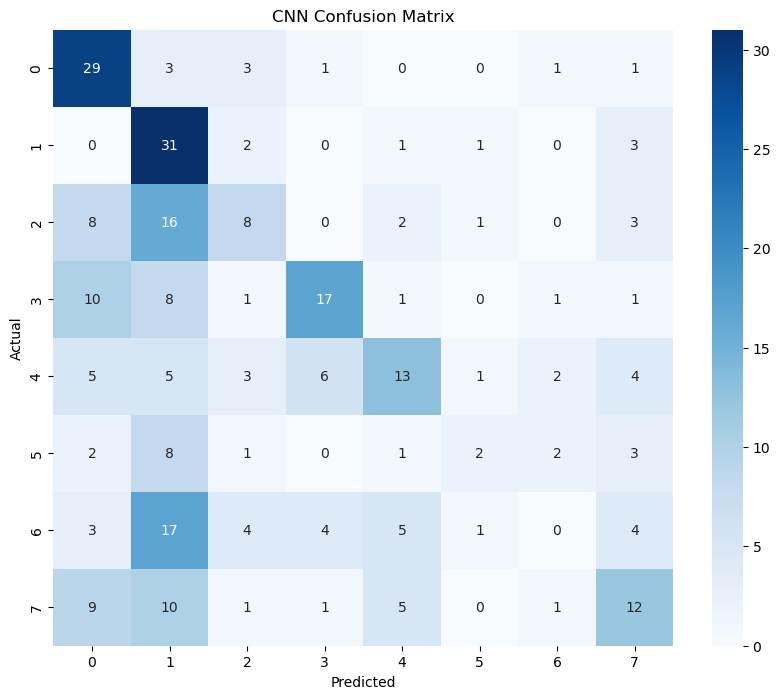

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [39]:
model.save("cnn_emotion_model.h5")